### Data Acquisition

The yfinance will grab the actual market history

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define your universe
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM', 'V', 'PG', 'KO', 'PEP']

# 2. Download data
# We add 'auto_adjust=False' to ensure we get 'Adj Close' specifically
data = yf.download(tickers, start="2019-01-01", end="2024-01-01", auto_adjust=False)

# 3. Safely grab 'Adj Close'
if 'Adj Close' in data.columns:
    raw_data = data['Adj Close']
else:
    # Fallback: If Adj Close isn't there, use 'Close'
    print("Adj Close not found, using Close prices instead.")
    raw_data = data['Close']

print(f"Successfully downloaded data for: {list(raw_data.columns)}")
raw_data.head()

[*********************100%***********************]  10 of 10 completed

Successfully downloaded data for: ['AAPL', 'AMZN', 'GOOGL', 'JPM', 'KO', 'MSFT', 'PEP', 'PG', 'TSLA', 'V']


Ticker,AAPL,AMZN,GOOGL,JPM,KO,MSFT,PEP,PG,TSLA,V
Date,,,,,,,,,,
2019-01-02,37.469208,76.956497,52.301723,80.836517,37.582687,94.397156,87.605774,75.348259,20.674667,126.329437
2019-01-03,33.736992,75.014000,50.853199,79.687660,37.350445,90.924484,86.788101,74.819962,20.024000,121.776970
2019-01-04,35.177208,78.769501,53.461632,82.625404,38.095215,95.153275,88.567780,76.347084,21.179333,127.023232
2019-01-07,35.098907,81.475502,53.355026,82.682846,37.598709,95.274651,87.806190,76.041656,22.330667,129.313766
2019-01-08,35.768009,82.829002,53.823650,82.526939,38.023140,95.965446,88.647934,76.322311,22.356667,130.017105


### Feature Engineering

Calculating the **Volatility** and **Performance** to create the coordinates the AI will need to group similar stocks 

In [3]:
# 1. Calculate Daily Returns
returns = raw_data.pct_change()

# 2. Calculate Annualized Volatility (Standard Deviation)
volatility = returns.std() * np.sqrt(252)

# 3. Calculate Cumulative Return (Performance)
performance = (raw_data.iloc[-1] / raw_data.iloc[0]) - 1

# 4. Create a Feature DataFrame for Clustering
features = pd.DataFrame({
    'Volatility': volatility,
    'Performance': performance
}).dropna()

print(features)

        Volatility  Performance
Ticker                         
AAPL      0.322346     4.080841
AMZN      0.352214     0.974362
GOOGL     0.318100     1.648955
JPM       0.318977     0.993328
KO        0.213941     0.467842
MSFT      0.304908     2.916134
PEP       0.216835     0.790349
PG        0.211613     0.821997
TSLA      0.647000    11.018573
V         0.280405     1.026645


### K-Means Clustering

The StandardScaler ensures that **Performance** and **Volatility** are treated with equal importance. The scatter plot will visually prove that your AI has successfully grouped "Tech" together and "Conservative" stocks together.

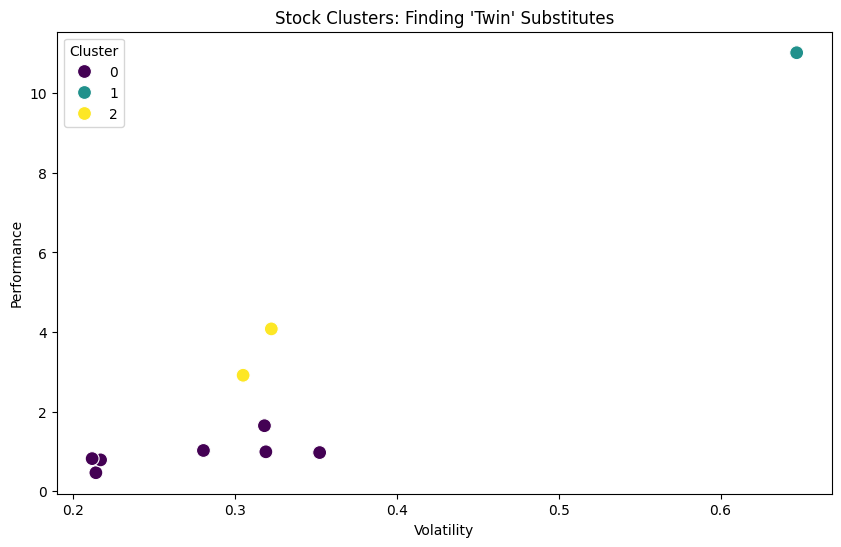

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale the data (Crucial for K-Means)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
features['Cluster'] = kmeans.fit_predict(scaled_features)

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=features, x='Volatility', y='Performance', hue='Cluster', palette='viridis', s=100)
plt.title("Stock Clusters: Finding 'Twin' Substitutes")
plt.show()

### Identifying Harvesting Opportunities

bridges the gap between **ML Theory** and **Tax Logic**. It checks if a stock in your portfolio has dropped enough to trigger a tax benefit (>10%) and then uses the cluster results from Cell 3 to suggest a "twin" stock to buy.

In [7]:
# Simulate a mock portfolio
portfolio = {'TSLA': 200.0, 'AAPL': 190.0} # Ticker: Purchase Price

def check_harvest(ticker, current_price, purchase_price):
    loss = (current_price - purchase_price) / purchase_price
    if loss <= -0.10: # 10% threshold
        return True, loss
    return False, loss

# Check current prices (using the last row of our data)
last_prices = raw_data.iloc[-1]

for ticker, cost_basis in portfolio.items():
    is_eligible, pct = check_harvest(ticker, last_prices[ticker], cost_basis)
    if is_eligible:
        # Find a substitute from the same cluster
        my_cluster = features.loc[ticker, 'Cluster']
        substitutes = features[features['Cluster'] == my_cluster].index.tolist()
        substitutes.remove(ticker)
        print(f"🚨 HARVEST: {ticker} is down {pct:.2%}. Sell for tax loss and buy {substitutes[0]}.")
    else:
        print(f"✅ HOLD: {ticker} is only at {pct:.2%}. No harvest needed.")

✅ HOLD: TSLA is only at 24.24%. No harvest needed.
✅ HOLD: AAPL is only at 0.20%. No harvest needed.
